In [1]:
import pandas as pd
import numpy as np

__Objective 1: Import the data from both tabs in the "Bank_Churn_Messy" Excel file__

In [2]:
#reading both sheets from excel
bank_churny_messy_file = pd.ExcelFile("Bank_Churn_Messy.xlsx")
customer_info = pd.read_excel(bank_churny_messy_file, "Customer_Info")
account_info = pd.read_excel(bank_churny_messy_file, "Account_Info")

__Objective 1: Use a left join to join "Account_Info" to "Customer_Info" using the CustomerID column__

In [3]:
#left join account_info with customer_info
left_join_info = pd.merge(customer_info, account_info, how='left', on='CustomerId')

__Objective 1: Check for and remove duplicate rows and columns__

In [4]:
#1st we group the CustomerIds based on their counts
group_customers = left_join_info.groupby(by='CustomerId').size()

#now we filter the series by the records that have a count greater than 1 so we know there are duplicate entries
group_customers_filtered = group_customers[group_customers > 1]

#we drop the duplicate rows 
left_join_info = left_join_info.drop_duplicates(subset='CustomerId', keep='first')

#checking if the columns tenure_x and tenure_y hold the same values.
left_join_info['Tenure_x'].equals(left_join_info['Tenure_y'])
#the above check returned true, meaning we have repeated columns 
#we are going to drop column 'Tenure_y' and rename column 'Tenure_x' to 'Tenure'
left_join_info = left_join_info.drop(columns=['Tenure_y'])
left_join_info = left_join_info.rename(columns={'Tenure_x' : 'Tenure'})


In [5]:
#checking data types
left_join_info.head(n=5)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,No,0
5,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1,€125510.82,1,Yes,Yes,0


__Objective 2: Check the data types for each column and make any necessary fixes and Replace missing values in categorical columns with "MISSING", and missing values in numeric columns with the median__

In [6]:
#first let's check the datatypes of each column
left_join_info.dtypes

#on balance column, remove the € symbol. Same on EstimatedSalary column. 
left_join_info['Balance'] = left_join_info['Balance'].str.replace('€', '', regex = True)
left_join_info['EstimatedSalary'] = left_join_info['EstimatedSalary'].str.replace('€', '', regex = True)

#on Salary and Balance column, turn data type into a float 
left_join_info = left_join_info.astype({"Balance": "float64"})
left_join_info = left_join_info.astype({"EstimatedSalary": "float64"})

#check whether there are missing values 
left_join_info.isna().sum()

#replace null surnames with "MISSING"
left_join_info['Surname'] = left_join_info['Surname'].fillna('MISSING')

#finding the median for the age column and subbing missing values by median
median_age = left_join_info['Age'].median()
left_join_info['Age'] = left_join_info['Age'].fillna(median_age)

#on age column, switch data type from float to int. 
left_join_info = left_join_info.astype({"Age": "int64"})

#on Exited column, switch the 0/1 to boolean True/False
left_join_info = left_join_info.astype({"Exited": "bool"})

#-on HasCrCard and IsActiveMember columns, change it to a boolean 
left_join_info['HasCrCard'] = left_join_info['HasCrCard'] == 'Yes'
left_join_info['IsActiveMember'] = left_join_info['IsActiveMember'] == 'Yes'

left_join_info.dtypes
#left_join_info.head(n=5)

#-on geography column, record that says FRA or French, i switch it to France

CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
EstimatedSalary    float64
Balance            float64
NumOfProducts        int64
HasCrCard             bool
IsActiveMember        bool
Exited                bool
dtype: object

__Objective 2: Profile the numeric columns in the data. Are there any extreme or non-sensical values? If so, impute them with the median of the column.__

In [7]:
#let's describe our dataframe statistically
left_join_info.describe()

#computing the median for the EstimatedSalary values
median_estimated_salary = left_join_info['EstimatedSalary'].median()

#imputing the median onto the negative values of EstimatedSalary
left_join_info.loc[left_join_info['EstimatedSalary'] < 0, 'EstimatedSalary'] = median_estimated_salary



__Objective 2: Combine any variations in country names in the "Geography" column to a single value per country__

In [28]:
#seeing unique values in Geography column
left_join_info['Geography'].unique()

#substituting FRA/French by France
left_join_info['Geography'] = np.where((left_join_info['Geography'] == 'FRA' )| (left_join_info['Geography'] == 'French'), 'France', left_join_info['Geography'])

__Objective 3: Build a bar chart displaying the count of churners (Exited=1) vs. non-churners (Exited=0)__

<Axes: xlabel='Characterization', ylabel='Frequency'>

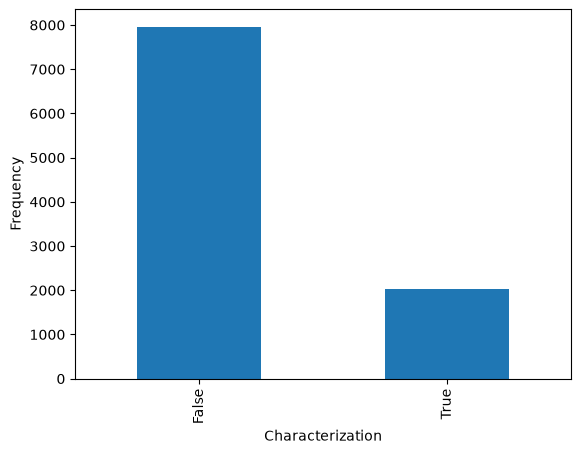

In [21]:
#Counting churners (Exited = True) and non-churners (Exited = False)
count = left_join_info['Exited'].value_counts()

#building a bar chart using these values
count.plot.bar(xlabel= 'Characterization', ylabel='Frequency')

__Objective 3:Explore the categorical variables vs. the target, and look at the percentage of Churners by “Geography” and “Gender”__

In [33]:
#we need to get a dataframe but for churners only. so the rows that stay have Exited = True
#we get the total number of churners 
#then for each of the countries and genders we calculate how many churners. 
#then for the % we do churners per country/gender divided by total

churners = left_join_info[left_join_info['Exited'] == True]

#churners by country
churners_france = churners[churners['Geography'] == 'France']
count_churners_france = churners_france.value_counts()
print (count_churners_france)
churners_spain = churners[churners['Geography'] == 'Spain']
churners_germany = churners[churners['Geography'] == 'Germany']


#churners by gender
churners_male = churners[churners['Gender'] == 'Male']
churners_female = churners[churners['Gender'] == 'Female']




CustomerId  Surname      CreditScore  Geography  Gender  Age  Tenure  EstimatedSalary  Balance    NumOfProducts  HasCrCard  IsActiveMember  Exited
15634602    Hargrave     619          France     Female  42   2       101348.88        0.00       1              True       True            True      1
15619304    Onio         502          France     Female  42   8       113931.57        159660.80  3              False      False           True      1
15794171    Lombardo     475          France     Female  45   0       27822.99         134264.04  1              False      False           True      1
15738148    Clarke       465          France     Female  51   8       181297.65        122522.32  1              False      False           True      1
15755196    Lavine       834          France     Female  49   2       194365.76        131394.56  1              False      False           True      1
                                                                                             